# Task 3.1 — Implementación base del Filtrado de Partículas

En esta sección se implementa desde cero un sistema de seguimiento probabilístico para el patio LogiTrack.

Vianka Vanessa Castro Ordoñez - 23201
Ricardo Arturo Godínez Sánchez - 23247

El sistema trabaja con:
- 20 carriles numerados del 0 al 19.
- Un vehículo cuya posición real es oculta.
- Sensores RFID ruidosos.
- Un filtro de partículas con K = 5 partículas, debido a la restricción de memoria del microcontrolador.

El objetivo es simular la trayectoria real del vehículo, generar observaciones ruidosas del sensor y estimar la posición del vehículo usando Filtrado de Partículas.

## Imports y Parámetros Iniciales 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Semilla para que los resultados sean reproducibles
np.random.seed(42)

# Parámetros
CARRILES = 20
K = 5

## TASK 3.1.1 — Simulación de la trayectoria real del vehículo

El vehículo puede moverse de tres formas en cada paso de tiempo:

- moverse un carril a la izquierda (-1),
- quedarse en el mismo carril (0),
- moverse un carril a la derecha (+1).

Cada movimiento tiene la misma probabilidad.

Como el patio solo tiene carriles del 0 al 19, se aplica reflexión en los bordes. Es decir, si el vehículo intenta salir del rango permitido, rebota hacia adentro.

In [2]:

def transicion(h_prev):
    """
    Modelo de transición del vehículo.

    Recibe la posición anterior h_prev y devuelve una nueva posición.
    El vehículo puede moverse -1, 0 o +1 con igual probabilidad.
    Si intenta salirse del rango de carriles, se refleja hacia adentro.
    """
    delta = np.random.choice([-1, 0, 1])
    nueva_pos = h_prev + delta

    # Reflexión en bordes
    if nueva_pos < 0:
        nueva_pos = 1
    elif nueva_pos >= CARRILES:
        nueva_pos = CARRILES - 2

    return nueva_pos

## Modelo de sensor

El sensor RFID es ruidoso. La lectura del sensor es más probable cuando coincide con la posición real del vehículo, pero también puede reportar carriles cercanos o errores.

Para el filtrado, esta función calcula qué tan probable es observar cierto sensor dado que la partícula está en un carril específico.

Este valor se usa como peso de cada partícula.

In [3]:
def emision(sensor, h):
    """
    Modelo de emisión o sensor.

    Calcula qué tan compatible es una lectura del sensor con una hipótesis h.
    Mientras más cerca esté el sensor de h, mayor será el peso.
    """
    dist = abs(sensor - h)

    if dist == 0:
        return 0.6
    elif dist == 1:
        return 0.2
    else:
        return 0.2 / (CARRILES - 2)

## Generación de observaciones del sensor

Para simular el sistema completo, primero se genera una trayectoria real oculta del vehículo.

Luego, en cada paso, se genera una observación del sensor a partir de la posición real.

Como el sensor es probabilístico, se construye una distribución de probabilidad sobre los 20 carriles y se normaliza para poder seleccionar una lectura válida.

In [4]:
def generar_observacion_sensor(h_real):
    """
    Genera una lectura de sensor a partir de la posición real del vehículo.

    Se calculan los pesos de emisión para todos los carriles posibles
    y luego se normalizan para formar una distribución de probabilidad.
    """
    probabilidades = np.array([emision(sensor, h_real) for sensor in range(CARRILES)])
    probabilidades = probabilidades / probabilidades.sum()

    sensor = np.random.choice(np.arange(CARRILES), p=probabilidades)
    return sensor

## Simulación del vehículo

La función simular_vehiculo(pasos) genera:

1. La trayectoria real oculta del vehículo.
2. Las observaciones ruidosas del sensor RFID.

La trayectoria real no será conocida por el filtro. Solo se usa después para comparar qué tan buena fue la estimación.

In [5]:
def simular_vehiculo(pasos, inicio=None):
    """
    Simula la trayectoria real oculta del vehículo y las observaciones del sensor.

    Parámetros:
    - pasos: cantidad de pasos de tiempo.
    - inicio: posición inicial opcional. Si no se indica, se elige aleatoriamente.

    Retorna:
    - trayectoria_real: posiciones reales del vehículo.
    - observaciones: lecturas ruidosas del sensor.
    """
    if inicio is None:
        h_real = np.random.randint(0, CARRILES)
    else:
        h_real = inicio

    trayectoria_real = []
    observaciones = []

    for _ in range(pasos):
        trayectoria_real.append(h_real)

        sensor = generar_observacion_sensor(h_real)
        observaciones.append(sensor)

        h_real = transicion(h_real)

    return np.array(trayectoria_real), np.array(observaciones)

## Filtrado de Partículas

El filtro de partículas aproxima la posición del vehículo usando solo K = 5 partículas.

En cada paso se realizan tres fases:

1. Proponer: cada partícula se mueve usando el modelo de transición.
2. Ponderar: cada partícula recibe un peso según qué tan bien explica la lectura del sensor.
3. Remuestrear: se seleccionan nuevas partículas con reemplazo, usando como probabilidad los pesos normalizados.

La estimación final en cada paso será la media de las partículas.

In [6]:
def filtro_particulas(observaciones, K=5):
    """
    Implementa el Filtrado de Partículas para LogiTrack.

    Parámetros:
    - observaciones: lecturas del sensor en cada paso de tiempo.
    - K: número de partículas activas.

    Retorna:
    - estimaciones: media de las partículas en cada paso.
    - historial_particulas: partículas después del remuestreo en cada paso.
    """
    # Inicialización aleatoria de partículas
    particulas = np.random.randint(0, CARRILES, K)

    estimaciones = []
    historial_particulas = []

    for sensor in observaciones:
        # Paso 1: Proponer nuevas partículas usando el modelo de transición
        propuestas = np.array([transicion(h) for h in particulas])

        # Paso 2: Ponderar según la lectura del sensor
        pesos = np.array([emision(sensor, h) for h in propuestas])
        pesos_norm = pesos / pesos.sum()

        # Paso 3: Remuestrear con reemplazo y proporcional a los pesos
        indices = np.random.choice(
            np.arange(K),
            size=K,
            replace=True,
            p=pesos_norm
        )

        particulas = propuestas[indices]

        # Guardar resultados
        estimaciones.append(np.mean(particulas))
        historial_particulas.append(particulas.copy())

    return np.array(estimaciones), np.array(historial_particulas)

## Ejecución de una simulación

Ahora se ejecuta una simulación de ejemplo con 30 pasos.

Se genera la trayectoria real, las observaciones del sensor y la estimación producida por el filtro de partículas.

In [7]:
pasos = 30

trayectoria_real, observaciones = simular_vehiculo(pasos)
estimaciones, historial_particulas = filtro_particulas(observaciones, K=K)

print("Trayectoria real:")
print(trayectoria_real)

print("\nObservaciones del sensor:")
print(observaciones)

print("\nEstimaciones del filtro:")
print(np.round(estimaciones, 2))

Trayectoria real:
[6 7 6 6 7 6 7 7 7 6 6 5 6 7 8 9 8 9 8 7 7 7 8 7 8 8 8 8 8 8]

Observaciones del sensor:
[ 7  8  6  5  7  6  2  7  6  6  6  5  6  7  8 18  4  9  6 16  7  6  8  8
 10  8  8  8  3  9]

Estimaciones del filtro:
[5.8 3.4 4.  4.8 5.6 6.  6.2 7.2 7.  6.8 6.4 6.  6.  6.8 7.8 7.8 7.2 8.6
 7.  6.8 6.6 6.2 8.2 8.  8.8 8.4 8.  7.4 7.2 8.6]


## Visualización de resultados

La gráfica muestra:

- La trayectoria real del vehículo.
- La estimación del filtro, calculada como la media de las partículas.
- La distribución de partículas en cada paso de tiempo.

Los puntos dispersos permiten observar si las partículas están concentradas o si mantienen diversidad.

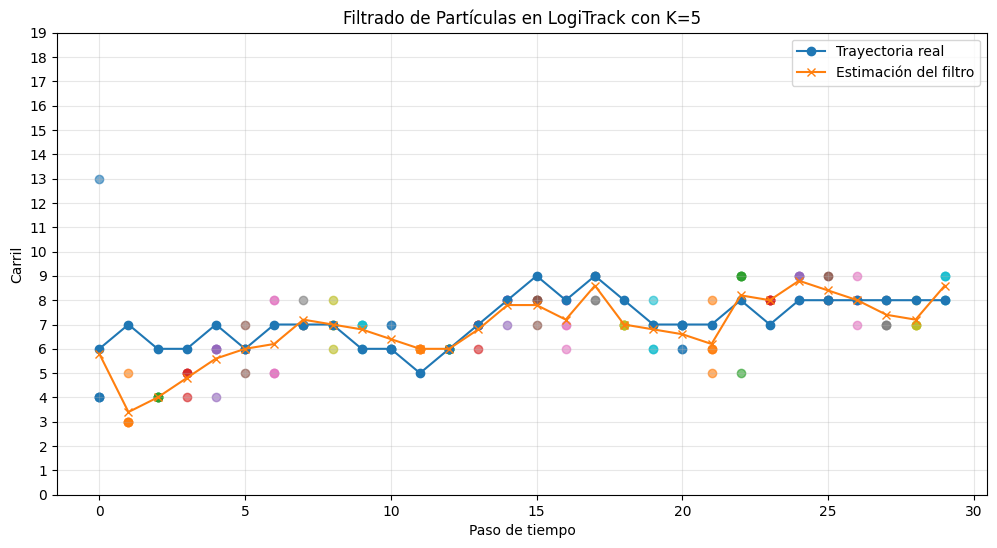

In [8]:
tiempos = np.arange(pasos)

plt.figure(figsize=(12, 6))

# Trayectoria real
plt.plot(tiempos, trayectoria_real, marker='o', label='Trayectoria real')

# Estimación del filtro
plt.plot(tiempos, estimaciones, marker='x', label='Estimación del filtro')

# Partículas como puntos dispersos
for t in range(pasos):
    x = np.full(K, t)
    y = historial_particulas[t]
    plt.scatter(x, y, alpha=0.6)

plt.title('Filtrado de Partículas en LogiTrack con K=5')
plt.xlabel('Paso de tiempo')
plt.ylabel('Carril')
plt.yticks(range(CARRILES))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Mini Interpretación 

En esta simulación, la línea de la trayectoria real representa la posición verdadera del vehículo, mientras que la línea de estimación representa la media de las partículas del filtro.

Cuando las partículas se concentran cerca de la trayectoria real, el filtro está siguiendo correctamente al vehículo. Cuando las partículas se alejan o se concentran en una región incorrecta, el sistema puede estar perdiendo diversidad o siendo afectado por lecturas ruidosas del sensor.

